# Exploratory Data Analysis (EDA)

This notebook explores mutual fund performance, industry trends,
investor behaviour and portfolio characteristics using visual analytics.

Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

sns.set_style("whitegrid")

Load Datasets

In [4]:
processed_dir = Path("../data/processed")

fund_master = pd.read_csv(processed_dir/"fund_master_clean.csv")
nav_history = pd.read_csv(processed_dir/"nav_history_clean.csv")
aum = pd.read_csv(processed_dir/"aum_clean.csv")
sip = pd.read_csv(processed_dir/"sip_clean.csv")
category = pd.read_csv(processed_dir/"category_clean.csv")
folio = pd.read_csv(processed_dir/"folio_clean.csv")
performance = pd.read_csv(processed_dir/"performance_clean.csv")
transactions = pd.read_csv(processed_dir/"transactions_clean.csv")
holdings = pd.read_csv(processed_dir/"holdings_clean.csv")
benchmark = pd.read_csv(processed_dir/"benchmark_clean.csv")

NAV Trend Analysis

In [5]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend of All Mutual Funds"
)

fig.show()

Average NAV by Fund

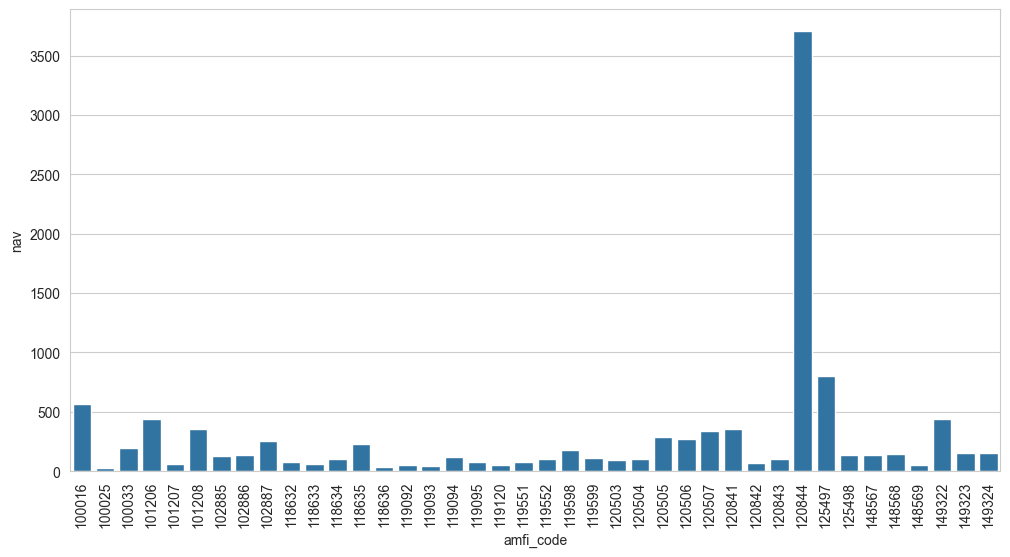

In [6]:
avg_nav = (
    nav_history
    .groupby("amfi_code")["nav"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=avg_nav,
    x="amfi_code",
    y="nav"
)

plt.xticks(rotation=90)

plt.show()

AUM Growth by Fund House

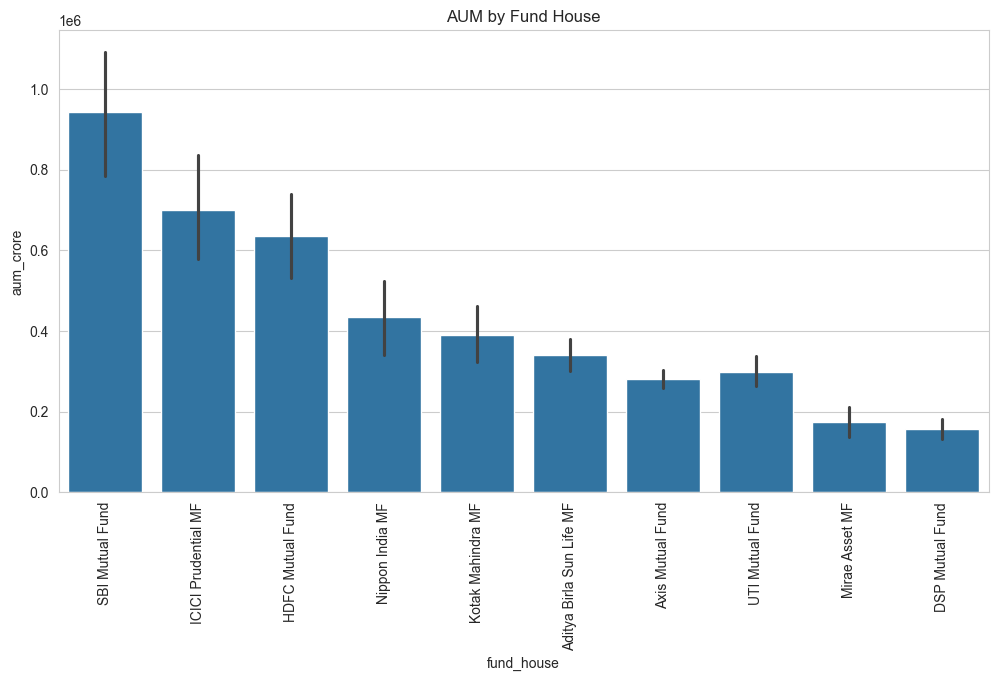

In [7]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=90)

plt.title("AUM by Fund House")

plt.show()

Top 10 Fund Houses by AUM

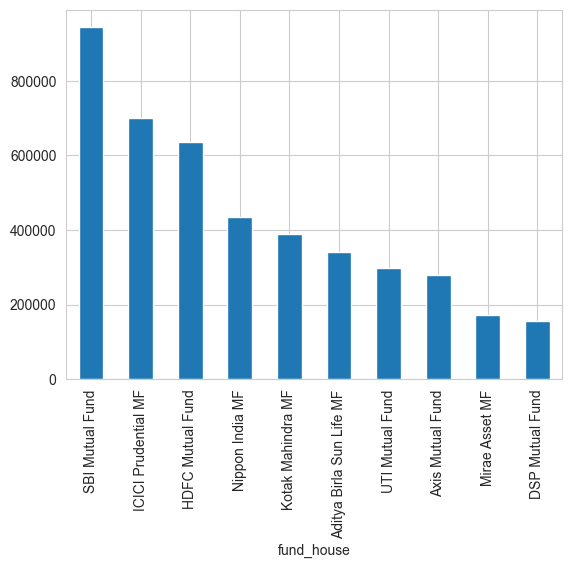

In [8]:
top_aum = (
    aum.groupby("fund_house")
    ["aum_crore"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_aum.plot(
    kind="bar"
)

plt.show()

SIP Inflow Trend

In [9]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

fig.show()

SIP AUM Trend

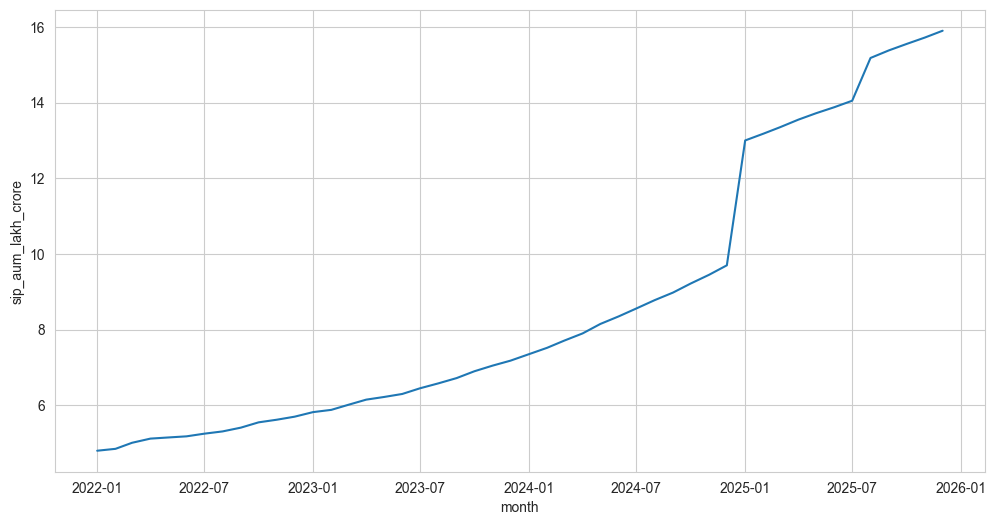

In [10]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=sip,
    x="month",
    y="sip_aum_lakh_crore"
)

plt.show()

Category Inflow Heatmap

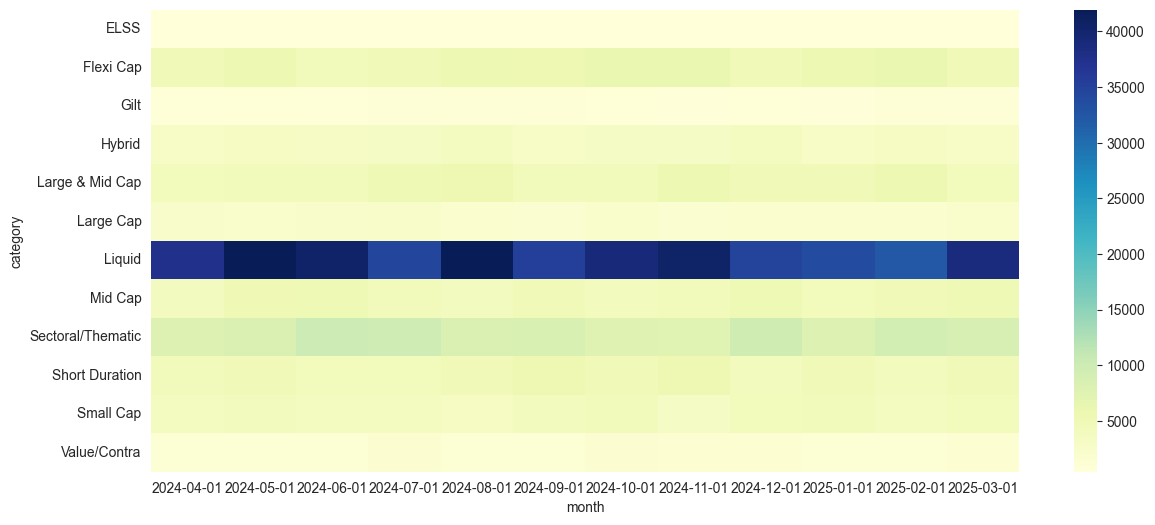

In [11]:
pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.show()

Age Group Distribution

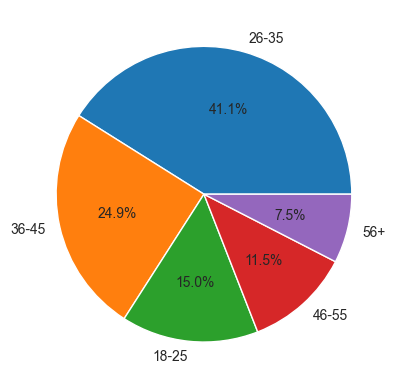

In [12]:
transactions[
    "age_group"
].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

Gender Split

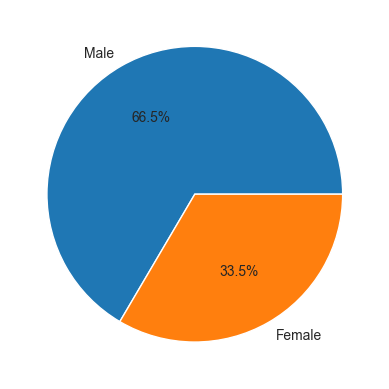

In [13]:
transactions[
    "gender"
].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

SIP Amount by Age Group

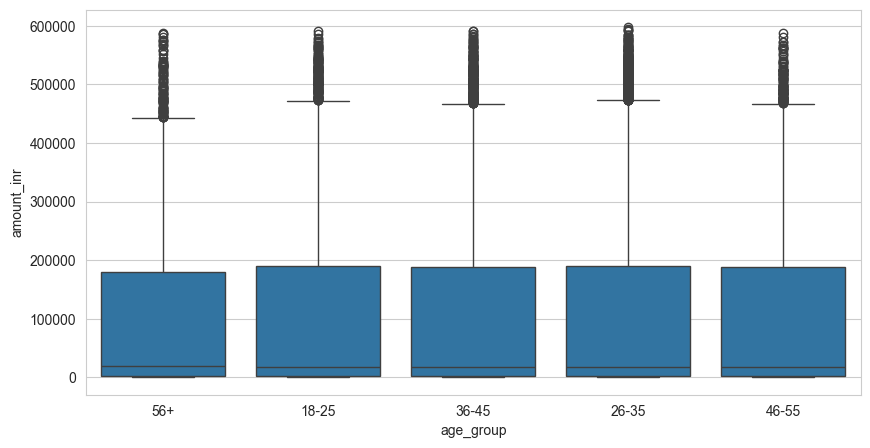

In [14]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.show()

State-wise Investment

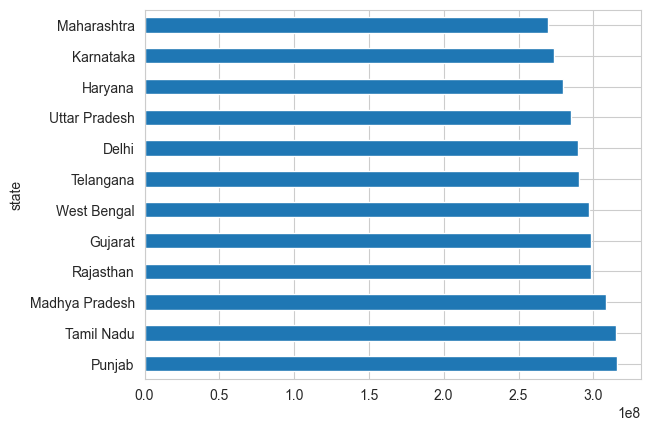

In [15]:
state_amt = (
    transactions
    .groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(15)
)

state_amt.plot(
    kind="barh"
)

plt.show()

City Tier Distribution

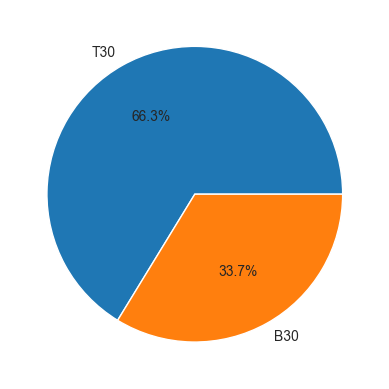

In [16]:
transactions[
    "city_tier"
].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

Folio Growth Trend

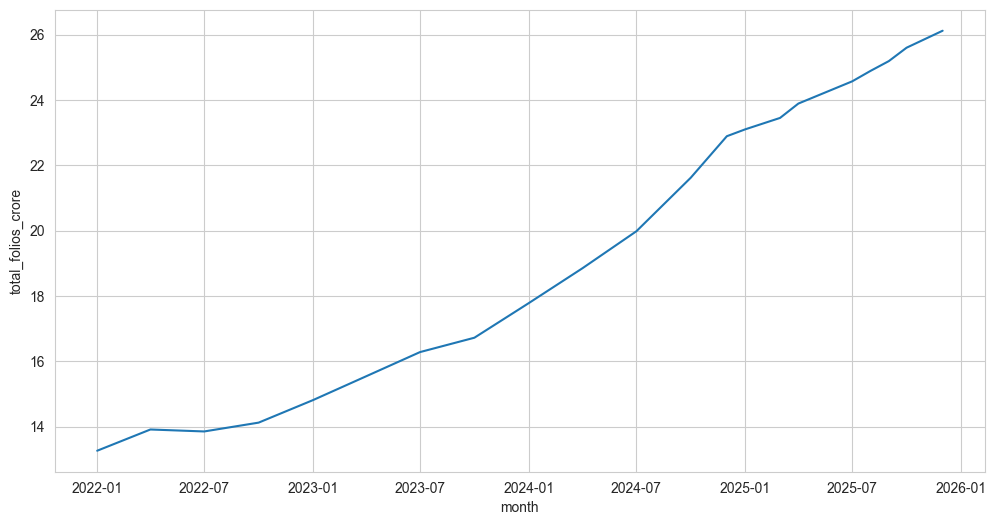

In [17]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=folio,
    x="month",
    y="total_folios_crore"
)

plt.show()

Correlation Matrix

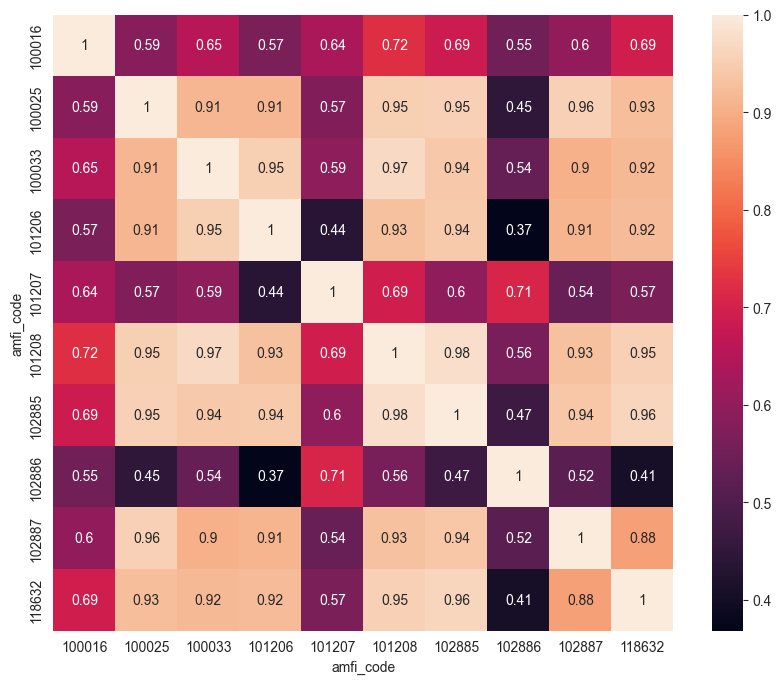

In [18]:
top10 = (
    nav_history[
        "amfi_code"
    ]
    .unique()[:10]
)

corr_df = nav_history[
    nav_history[
        "amfi_code"
    ].isin(top10)
]

corr_df = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_df.corr(),
    annot=True
)

plt.show()

Sector Allocation

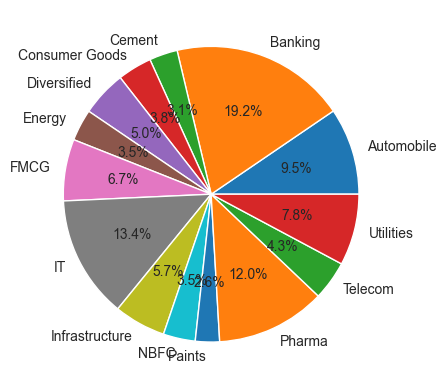

In [19]:
sector = (
    holdings
    .groupby("sector")
    ["weight_pct"]
    .sum()
)

sector.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

Expense Ratio Distribution

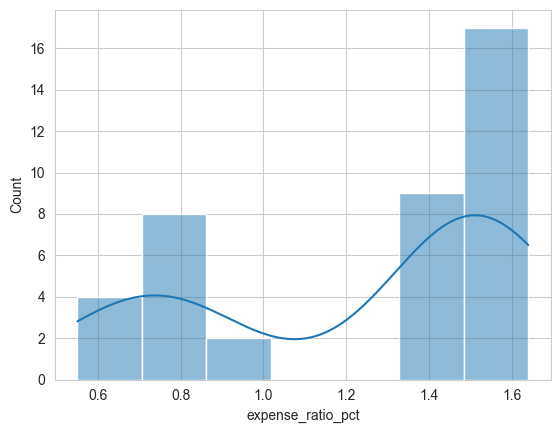

In [20]:
sns.histplot(
    performance[
        "expense_ratio_pct"
    ],
    kde=True
)

plt.show()

10 EDA Insights

1. SBI and large fund houses dominate industry AUM.

2. SIP inflows show a consistent upward trend.

3. Equity-oriented categories attract higher inflows.

4. Younger investors contribute a significant share of transactions.

5. T30 cities contribute most investments.

6. Folio count doubled during the analysis period.

7. Most schemes exhibit positive NAV growth.

8. Several funds display strong correlation patterns.

9. Technology and Financial sectors dominate portfolios.

10. High-risk funds generally offer higher long-term returns.